# House 6 multi-appliance NILM followed by four independent appliance forecasters

Run cells from top to bottom. Stage 1 trains one NILMFormer with one output channel per appliance using House 6. Stage 2 freezes that NILMFormer and trains a separate multi-step GRU forecaster for each appliance. Train, validation, and test are chronological portions of House 6; evaluation uses only its held-out test portion.

In [1]:
from pathlib import Path
import copy
import logging
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from IPython.display import clear_output, display

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "configs").is_dir() else cwd / "NILMFormer"
if not (PROJECT_ROOT / "scripts" / "run_one_expe.py").is_file():
    raise FileNotFoundError(f"Cannot find NILMFormer project under {PROJECT_ROOT}")
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.helpers.dataset import NILMDataset, NILMForecastDataset, NILMscaler
from src.helpers.metrics import NILMmetrics
from src.helpers.preprocessing import (
    REFIT_DataBuilder,
    UKDALE_DataBuilder,
    split_train_test_nilmdataset,
    split_train_test_pdl_nilmdataset,
)
from src.nilmformer.congif import NILMFormerConfig
from src.nilmformer.forecasting import NILMForecastPipeline
from src.nilmformer.model import NILMFormer

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s", force=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")

/home/dat/miniconda3/envs/nilm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-10-01 23:51:27,891 - WARNING - WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.14.1+cu130)
    Python  3.10.19 (you have 3.12.3)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Project: /run/media/dat/6647-B737/Research/NILM/NILM-code/NILMFormer
Device: cuda


In [2]:
# Experiment setup
DATASET = "REFIT"
HOUSE_ID = 6
APPLIANCES = ["WashingMachine", "Dishwasher", "Kettle", "Microwave"]
SAMPLING_RATE = "1min"
WINDOW_SIZE = 128
FORECAST_HORIZON = 64
TRAIN_FRACTION = 0.7
VALIDATION_FRACTION = 0.15
SEED = 0

with open(PROJECT_ROOT / "configs" / "expes.yaml", encoding="utf-8") as f:
    EXP_CONFIG = yaml.safe_load(f)
with open(PROJECT_ROOT / "configs" / "datasets.yaml", encoding="utf-8") as f:
    DATASET_CONFIG = yaml.safe_load(f)
APPLIANCE_CONFIGS = [DATASET_CONFIG[DATASET][name] for name in APPLIANCES]
APPLIANCE_NAMES = [config["app"] for config in APPLIANCE_CONFIGS]
N_APPLIANCES = len(APPLIANCES)
EXOGENOUS_VARIABLES = EXP_CONFIG["list_exo_variables"]
DATA_ROOT = PROJECT_ROOT / EXP_CONFIG["data_path"]
RESULT_DIR = PROJECT_ROOT / "result" / "joint_forecast" / f"REFIT_house{HOUSE_ID}_multiforecaster_{SAMPLING_RATE}_w{WINDOW_SIZE}_h{FORECAST_HORIZON}_seed{SEED}"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
NILM_CHECKPOINT = RESULT_DIR / "best_nilm_multi_appliance.pt"
FORECAST_CHECKPOINTS = {
    name: RESULT_DIR / f"best_forecaster_{name}.pt" for name in APPLIANCES
}
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Device: {DEVICE}; house: {HOUSE_ID}")
print(f"Appliance output order: {APPLIANCES}")
print(f"Forecast horizon: {FORECAST_HORIZON} steps per appliance")


Device: cuda; house: 6
Appliance output order: ['WashingMachine', 'Dishwasher', 'Kettle', 'Microwave']
Forecast horizon: 64 steps per appliance


In [3]:
# Create House 6 windows with L input samples followed by H future target samples.
builder_window_size = WINDOW_SIZE + FORECAST_HORIZON
common_houses = sorted(
    set.intersection(*(set(c["house_with_app_i"]) for c in APPLIANCE_CONFIGS))
)
if HOUSE_ID not in common_houses:
    raise ValueError(f"House {HOUSE_ID} does not contain all selected appliances: {common_houses}")
data_builder = REFIT_DataBuilder(
    data_path=str(DATA_ROOT / "REFIT" / "RAW_DATA_CLEAN") + os.sep,
    mask_app=APPLIANCE_NAMES,
    sampling_rate=SAMPLING_RATE,
    window_size=builder_window_size,
)
house_data, house_dates = data_builder.get_nilm_dataset(house_indicies=[HOUSE_ID])
if not 0 < TRAIN_FRACTION < 1 or not 0 < VALIDATION_FRACTION < 1 or TRAIN_FRACTION + VALIDATION_FRACTION >= 1:
    raise ValueError("Train and validation fractions must be positive and leave a test fraction")
if len(house_data) < 10:
    raise ValueError(f"House {HOUSE_ID} has too few valid windows: {len(house_data)}")
train_end = int(len(house_data) * TRAIN_FRACTION)
valid_end = int(len(house_data) * (TRAIN_FRACTION + VALIDATION_FRACTION))
if train_end < 1 or valid_end <= train_end or valid_end >= len(house_data):
    raise ValueError(f"Cannot split {len(house_data)} House {HOUSE_ID} windows")
house_splits = {
    "train": (house_data[:train_end], house_dates.iloc[:train_end].copy()),
    "valid": (house_data[train_end:valid_end], house_dates.iloc[train_end:valid_end].copy()),
    "test": (house_data[valid_end:], house_dates.iloc[valid_end:].copy()),
}
print(
    f"House {HOUSE_ID} windows: train={train_end}, validation={valid_end - train_end}, "
    f"test={len(house_data) - valid_end}"
)


House 6 windows: train=2431, validation=521, test=522


In [4]:
# Hyperparameters and datasets for four aligned appliance targets.
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0
PATIENCE_EARLY_STOPPING = 7
PATIENCE_LR = 3
FORECAST_HIDDEN_SIZE = 64

class MultiApplianceDataset(torch.utils.data.Dataset):
    """Aggregate and calendar inputs with all appliance histories and future labels."""
    def __init__(self, scaled_data, st_date):
        self.samples = scaled_data[:, :, :, :WINDOW_SIZE].copy()
        self.future_targets = scaled_data[:, 1:, 0, WINDOW_SIZE:].copy()
        self.future_states = scaled_data[:, 1:, 1, WINDOW_SIZE:].copy()
        self.nilm_data = NILMDataset(
            self.samples,
            st_date=st_date,
            list_exo_variables=EXOGENOUS_VARIABLES,
            freq=SAMPLING_RATE,
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        aggregate = self.nilm_data[idx][0]
        appliance = self.samples[idx, 1:, 0, :].copy()
        state = self.samples[idx, 1:, 1, :].copy()
        return aggregate, appliance, state, self.future_targets[idx].copy()

class ApplianceForecaster(nn.Module):
    """Independent one-appliance GRU that forecasts H future power values."""
    def __init__(self, hidden_size, horizon):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, appliance_history):
        # Input [batch, 1, input_steps]; output [batch, horizon].
        sequence, _ = self.gru(appliance_history.transpose(1, 2))
        return self.head(sequence[:, -1, :])

# Fit scaling on the training period only, then reuse it for validation and test.
scaler = NILMscaler(
    power_scaling_type=EXP_CONFIG["power_scaling_type"],
    appliance_scaling_type=EXP_CONFIG["appliance_scaling_type"],
)
train_raw, train_dates = house_splits["train"]
scaler.fit(train_raw.copy())
if scaler.appliance_scaling_type == "SameAsPower":
    scaler.n_appliance = N_APPLIANCES
    scaler.appliance_stat1 = [scaler.power_stat1] * N_APPLIANCES
    scaler.appliance_stat2 = [scaler.power_stat2] * N_APPLIANCES
if scaler.n_appliance != N_APPLIANCES or len(scaler.appliance_stat2) != N_APPLIANCES:
    raise ValueError(
        f"Scaler channel mismatch: data shape={train_raw.shape}, "
        f"n_appliance={scaler.n_appliance}, stats={len(scaler.appliance_stat2)}"
    )

def make_dataset(split_name):
    raw_data, dates = house_splits[split_name]
    scaled_data = scaler.transform(raw_data.copy())
    return MultiApplianceDataset(scaled_data, dates)

train_dataset = make_dataset("train")
valid_dataset = make_dataset("valid")
test_dataset = make_dataset("test")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
forecast_thresholds = np.asarray(
    [data_builder.appliance_param[name]["min_threshold"] for name in APPLIANCE_NAMES],
    dtype=np.float32,
)
print(f"Train={len(train_dataset)}, validation={len(valid_dataset)}, test={len(test_dataset)}")


Train=2431, validation=521, test=522


In [5]:
# STAGE 1 — Train one NILMFormer that estimates all four appliance power histories.
# The output channel order follows APPLIANCES and must stay unchanged throughout this notebook.
nilm_config = NILMFormerConfig(
    c_in=1,
    c_embedding=2 * len(EXOGENOUS_VARIABLES),
    c_out=N_APPLIANCES,
)
nilm_model = NILMFormer(nilm_config).to(DEVICE)
nilm_criterion = nn.MSELoss()
nilm_optimizer = torch.optim.AdamW(
    nilm_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
nilm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    nilm_optimizer, mode="min", patience=PATIENCE_LR, eps=1e-7
)
nilm_history = []
best_nilm_valid = float("inf")
best_nilm_state = None
nilm_bad_epochs = 0

for epoch in tqdm(range(EPOCHS), desc="Train multi-appliance NILM", unit="epoch"):
    # Fit one epoch over shuffled training windows.
    nilm_model.train()
    train_loss = 0.0
    for aggregate, appliance, _, _ in train_loader:
        aggregate = aggregate.float().to(DEVICE)
        appliance = appliance.float().to(DEVICE)
        nilm_optimizer.zero_grad(set_to_none=True)
        appliance_pred = nilm_model(aggregate)
        loss = nilm_criterion(appliance_pred, appliance)
        loss.backward()
        nilm_optimizer.step()
        train_loss += float(loss.item())

    # Use held-out later windows to select weights and adjust the learning rate.
    nilm_model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for aggregate, appliance, _, _ in valid_loader:
            appliance_pred = nilm_model(aggregate.float().to(DEVICE))
            valid_loss += float(nilm_criterion(appliance_pred, appliance.float().to(DEVICE)).item())
    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss / max(len(train_loader), 1),
        "valid_loss": valid_loss / max(len(valid_loader), 1),
    }
    nilm_history.append(row)
    nilm_scheduler.step(row["valid_loss"])
    print(f"NILM epoch {epoch + 1}/{EPOCHS}: train={row['train_loss']:.6f}, valid={row['valid_loss']:.6f}")

    # Retain the best validation model; stop after the configured patience.
    if row["valid_loss"] < best_nilm_valid:
        best_nilm_valid = row["valid_loss"]
        best_nilm_state = {k: v.detach().cpu().clone() for k, v in nilm_model.state_dict().items()}
        nilm_bad_epochs = 0
        torch.save({
            "model_state_dict": best_nilm_state,
            "history": nilm_history,
            "best_valid_loss": float(best_nilm_valid),
            "house": HOUSE_ID,
            "appliances": APPLIANCES,
            "window_size": WINDOW_SIZE,
            "forecast_horizon": FORECAST_HORIZON,
            "scaler_state": {
                "power_scaling_type": scaler.power_scaling_type,
                "appliance_scaling_type": scaler.appliance_scaling_type,
                "power_stat1": float(scaler.power_stat1),
                "power_stat2": float(scaler.power_stat2),
                "appliance_stat1": [float(v) for v in scaler.appliance_stat1],
                "appliance_stat2": [float(v) for v in scaler.appliance_stat2],
            },
        }, NILM_CHECKPOINT)
    else:
        nilm_bad_epochs += 1
        if nilm_bad_epochs >= PATIENCE_EARLY_STOPPING:
            print("NILM early stopping")
            break

if best_nilm_state is None:
    raise RuntimeError("NILM training did not produce a validation checkpoint")
nilm_model.load_state_dict(best_nilm_state)
print(f"Best NILM checkpoint: {NILM_CHECKPOINT}")


Train multi-appliance NILM:   7%|▋         | 1/15 [00:03<00:52,  3.77s/epoch]

NILM epoch 1/15: train=0.000272, valid=0.000286


Train multi-appliance NILM:  13%|█▎        | 2/15 [00:06<00:44,  3.41s/epoch]

NILM epoch 2/15: train=0.000213, valid=0.000198


Train multi-appliance NILM:  20%|██        | 3/15 [00:10<00:39,  3.31s/epoch]

...

NILM epoch 13/15: train=0.000076, valid=0.000080


Train multi-appliance NILM:  93%|█████████▎| 14/15 [00:47<00:03,  3.39s/epoch]

NILM epoch 14/15: train=0.000072, valid=0.000079


Train multi-appliance NILM: 100%|██████████| 15/15 [00:50<00:00,  3.37s/epoch]

NILM epoch 15/15: train=0.000070, valid=0.000075
Best NILM checkpoint: /run/media/dat/6647-B737/Research/NILM/NILM-code/NILMFormer/result/joint_forecast/REFIT_house6_multiforecaster_1min_w128_h64_seed0/best_nilm_multi_appliance.pt


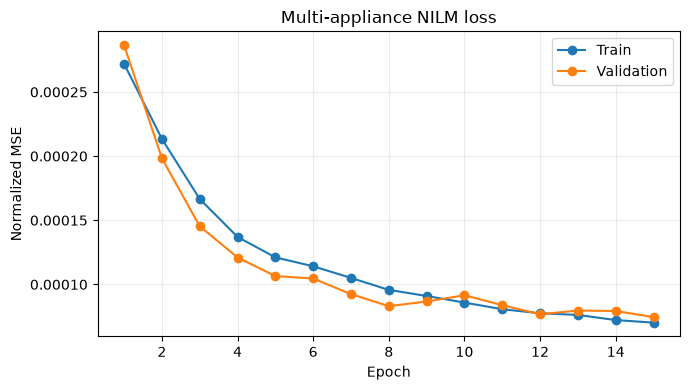

In [6]:
# Plot only NILM training and validation loss, in a one-row/two-column layout.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([r["epoch"] for r in nilm_history], [r["train_loss"] for r in nilm_history], marker="o", label="Train")
ax.plot([r["epoch"] for r in nilm_history], [r["valid_loss"] for r in nilm_history], marker="o", label="Validation")
ax.set_title("Multi-appliance NILM loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Normalized MSE")
ax.grid(alpha=.25)
ax.legend()
fig.tight_layout()
plt.show()


In [7]:
# STAGE 2 — Freeze the NILMFormer and generate its four appliance-history estimates.
# The independent forecasters learn from the same estimated histories they will receive at test time.
def predict_nilm_histories(loader):
    histories, future_targets = [], []
    nilm_model.eval()
    with torch.no_grad():
        for aggregate, _, _, future_target in loader:
            appliance_pred = nilm_model(aggregate.float().to(DEVICE))
            histories.append(appliance_pred.detach().cpu())
            future_targets.append(future_target.float())
    return torch.cat(histories, dim=0), torch.cat(future_targets, dim=0)

train_predicted_history, train_future_targets = predict_nilm_histories(train_loader)
valid_predicted_history, valid_future_targets = predict_nilm_histories(valid_loader)
forecast_models = {}
forecast_histories = {}
forecast_best_losses = {}

for app_idx, app_name in enumerate(APPLIANCES):
    print(f"\nTraining forecaster for {app_name}")
    torch.manual_seed(SEED + app_idx + 100)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + app_idx + 100)

    # Each forecaster sees only its corresponding NILM output channel and future label.
    x_train = train_predicted_history[:, app_idx:app_idx + 1, :]
    y_train = train_future_targets[:, app_idx, :]
    x_valid = valid_predicted_history[:, app_idx:app_idx + 1, :]
    y_valid = valid_future_targets[:, app_idx, :]
    app_train_loader = DataLoader(
        torch.utils.data.TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True
    )
    app_valid_loader = DataLoader(
        torch.utils.data.TensorDataset(x_valid, y_valid), batch_size=BATCH_SIZE, shuffle=False
    )

    forecaster = ApplianceForecaster(FORECAST_HIDDEN_SIZE, FORECAST_HORIZON).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(forecaster.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=PATIENCE_LR, eps=1e-7
    )
    history = []
    best_valid = float("inf")
    best_state = None
    bad_epochs = 0

    # Train and validate this appliance-specific forecast head independently.
    for epoch in tqdm(range(EPOCHS), desc=f"Forecast {app_name}", unit="epoch"):
        forecaster.train()
        train_loss = 0.0
        for history_input, future_target in app_train_loader:
            history_input = history_input.float().to(DEVICE)
            future_target = future_target.float().to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction = forecaster(history_input)
            loss = criterion(prediction, future_target)
            loss.backward()
            optimizer.step()
            train_loss += float(loss.item())

        forecaster.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for history_input, future_target in app_valid_loader:
                prediction = forecaster(history_input.float().to(DEVICE))
                valid_loss += float(criterion(prediction, future_target.float().to(DEVICE)).item())
        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss / max(len(app_train_loader), 1),
            "valid_loss": valid_loss / max(len(app_valid_loader), 1),
        }
        history.append(row)
        scheduler.step(row["valid_loss"])
        print(f"{app_name} epoch {epoch + 1}/{EPOCHS}: train={row['train_loss']:.6f}, valid={row['valid_loss']:.6f}")

        # Save the best validation state separately for this appliance.
        if row["valid_loss"] < best_valid:
            best_valid = row["valid_loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in forecaster.state_dict().items()}
            bad_epochs = 0
            torch.save({
                "model_state_dict": best_state,
                "history": history,
                "best_valid_loss": float(best_valid),
                "house": HOUSE_ID,
                "appliance": app_name,
                "window_size": WINDOW_SIZE,
                "forecast_horizon": FORECAST_HORIZON,
            }, FORECAST_CHECKPOINTS[app_name])
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE_EARLY_STOPPING:
                print(f"{app_name} early stopping")
                break

    if best_state is None:
        raise RuntimeError(f"No best forecast checkpoint for {app_name}")
    forecaster.load_state_dict(best_state)
    forecast_models[app_name] = forecaster
    forecast_histories[app_name] = history
    forecast_best_losses[app_name] = best_valid
print("Best validation forecast losses:", forecast_best_losses)



Training forecaster for WashingMachine


Forecast WashingMachine:  13%|█▎        | 2/15 [00:00<00:02,  6.47epoch/s]

WashingMachine epoch 1/15: train=0.006836, valid=0.004896
WashingMachine epoch 2/15: train=0.003495, valid=0.002280


Forecast WashingMachine:  27%|██▋       | 4/15 [00:00<00:01,  7.53epoch/s]

WashingMachine epoch 3/15: train=0.001444, valid=0.000806
WashingMachine epoch 4/15: train=0.000472, valid=0.000299


...

Microwave epoch 13/15: train=0.000084, valid=0.000123


Forecast Microwave:  93%|█████████▎| 14/15 [00:01<00:00,  7.73epoch/s]

Microwave epoch 14/15: train=0.000084, valid=0.000123


Forecast Microwave: 100%|██████████| 15/15 [00:01<00:00,  7.59epoch/s]

Microwave epoch 15/15: train=0.000084, valid=0.000123
Best validation forecast losses: {'WashingMachine': 0.0001897171263749442, 'Dishwasher': 0.0006624627411737391, 'Kettle': 0.0006918284860957, 'Microwave': 0.00012293888479083156}


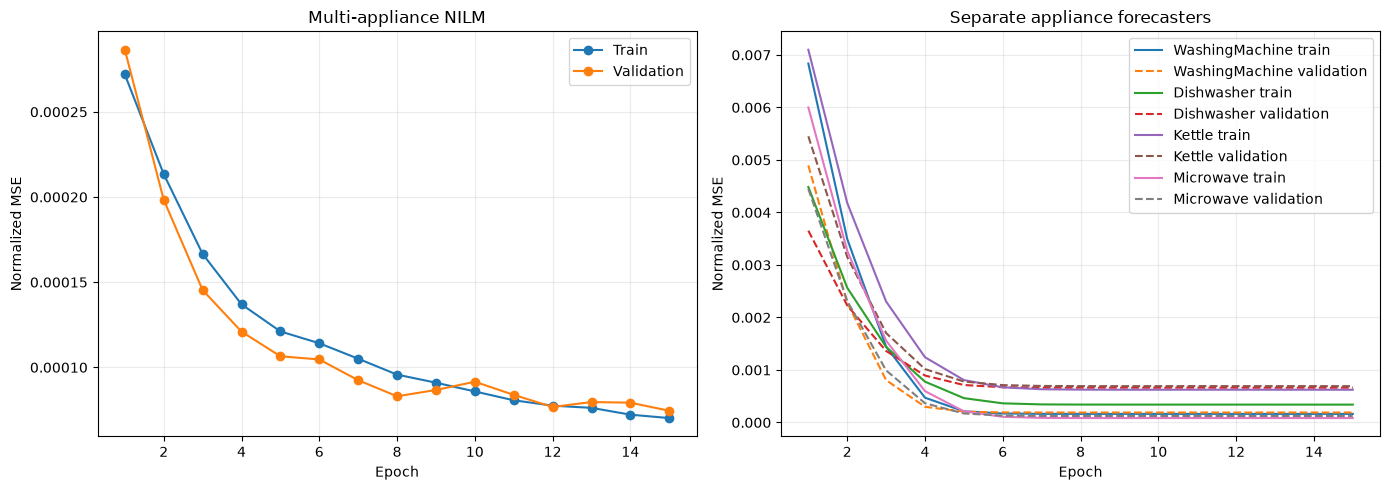

In [8]:
# Plot loss curves for the single NILM model and four independent forecast models.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([r["epoch"] for r in nilm_history], [r["train_loss"] for r in nilm_history], marker="o", label="Train")
axes[0].plot([r["epoch"] for r in nilm_history], [r["valid_loss"] for r in nilm_history], marker="o", label="Validation")
axes[0].set_title("Multi-appliance NILM")
for app_name in APPLIANCES:
    history = pd.DataFrame(forecast_histories[app_name])
    axes[1].plot(history["epoch"], history["train_loss"], label=f"{app_name} train")
    axes[1].plot(history["epoch"], history["valid_loss"], linestyle="--", label=f"{app_name} validation")
axes[1].set_title("Separate appliance forecasters")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Normalized MSE")
    ax.grid(alpha=.25)
    ax.legend()
fig.tight_layout()
plt.show()


In [11]:
# Evaluate NILM and each separate forecaster on House 6's held-out chronological test windows.
nilm_model.eval()
true_nilm, pred_nilm, true_states = [], [], []
true_future_by_app = {name: [] for name in APPLIANCES}
pred_future_by_app = {name: [] for name in APPLIANCES}
with torch.no_grad():
    for aggregate, appliance, state, future_target in test_loader:
        aggregate = aggregate.float().to(DEVICE)
        nilm_prediction = nilm_model(aggregate)
        true_nilm.append(scaler.inverse_transform_appliance(appliance.float().to(DEVICE)).cpu().numpy())
        pred_nilm.append(scaler.inverse_transform_appliance(nilm_prediction).cpu().numpy())
        true_states.append(state.numpy())
        for app_idx, app_name in enumerate(APPLIANCES):
            single_history = nilm_prediction[:, app_idx:app_idx + 1, :]
            forecast_scaled = forecast_models[app_name](single_history)
            true_future_by_app[app_name].append(future_target[:, app_idx, :].numpy())
            pred_future_by_app[app_name].append(forecast_scaled.cpu().numpy())

y_nilm = np.concatenate(true_nilm)
yhat_nilm = np.concatenate(pred_nilm)
states = np.concatenate(true_states)
yhat_nilm[yhat_nilm < forecast_thresholds.reshape(1, -1, 1)] = 0

def inverse_one_appliance(values, appliance_index):
    """Invert this channel with the matching appliance scaler statistics."""
    stat1 = scaler.appliance_stat1[appliance_index]
    stat2 = scaler.appliance_stat2[appliance_index]
    if scaler.appliance_scaling_type == "MinMax" or (
        scaler.appliance_scaling_type == "SameAsPower" and scaler.power_scaling_type == "MinMax"
    ):
        return values * (stat2 - stat1) + stat1
    return values * stat2 + stat1

metrics = NILMmetrics()
test_metrics = []
true_future_w_by_app, pred_future_w_by_app = {}, {}
for app_idx, app_name in enumerate(APPLIANCES):
    nilm_score = metrics(
        y=y_nilm[:, app_idx, :].ravel(),
        y_hat=yhat_nilm[:, app_idx, :].ravel(),
        y_state=states[:, app_idx, :].ravel(),
        y_hat_state=(yhat_nilm[:, app_idx, :] > forecast_thresholds[app_idx]).astype(np.int32).ravel(),
    )
    future_scaled = np.concatenate(true_future_by_app[app_name])
    prediction_scaled = np.concatenate(pred_future_by_app[app_name])
    true_future_w = inverse_one_appliance(future_scaled, app_idx)
    pred_future_w = np.maximum(inverse_one_appliance(prediction_scaled, app_idx), 0)
    true_future_w_by_app[app_name] = true_future_w
    pred_future_w_by_app[app_name] = pred_future_w
    forecast_score = metrics(y=true_future_w.ravel(), y_hat=pred_future_w.ravel())
    test_metrics.extend([
        {"house": HOUSE_ID, "appliance": app_name, "task": "NILM", **nilm_score},
        {"house": HOUSE_ID, "appliance": app_name, "task": "Forecast", **forecast_score},
    ])
test_summary = pd.DataFrame(test_metrics)
display(test_summary)


,house,appliance,task,MAE,MSE,RMSE,TECA,NDE,SAE,MR,ACCURACY,BALANCED_ACCURACY,PRECISION,RECALL,F1_SCORE
0,6,WashingMachine,NILM,3.697,2700.997,51.971,0.722,0.263,0.309,0.505,0.998,0.856,0.700,0.712,0.706
1,6,WashingMachine,Forecast,12.243,6032.614,77.670,-0.197,0.992,0.483,0.018,NaN,NaN,NaN,NaN,NaN
2,6,Dishwasher,NILM,3.971,3073.155,55.436,0.773,0.171,0.175,0.655,0.997,0.973,0.568,0.949,0.711
3,6,Dishwasher,Forecast,20.336,17243.583,131.315,-0.227,0.998,0.483,0.006,NaN,NaN,NaN,NaN,NaN
4,6,Kettle,NILM,8.441,8052.692,89.737,0.785,0.202,0.086,0.633,0.995,0.893,0.802,0.789,0.796
5,6,Kettle,Forecast,38.673,37925.373,194.744,-0.036,0.992,0.099,0.006,NaN,NaN,NaN,NaN,NaN
6,6,Microwave,NILM,6.780,5075.787,71.245,0.439,0.948,0.782,0.041,0.988,0.559,0.241,0.122,0.162
7,6,Microwave,Forecast,11.753,5090.622,71.349,-0.017,0.994,0.067,0.008,NaN,NaN,NaN,NaN,NaN


In [31]:
# Randomly choose a House 6 test window with real activity in the forecast horizon when available.
test_raw, _ = house_splits["test"]
active_test_indices = np.flatnonzero(
    np.any(test_raw[:, 1:, 1, WINDOW_SIZE:] > 0, axis=(1, 2))
)
candidates = active_test_indices if len(active_test_indices) else np.arange(len(test_dataset))
sample_idx = int(np.random.choice(candidates))
aggregate_x, appliance_y, _, future_y = test_dataset[sample_idx]
with torch.no_grad():
    nilm_prediction = nilm_model(
        torch.as_tensor(aggregate_x, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    )
print(f"Plotting House {HOUSE_ID} test sample {sample_idx}; future activity={bool(len(active_test_indices))}")


Plotting House 6 test sample 194; future activity=True


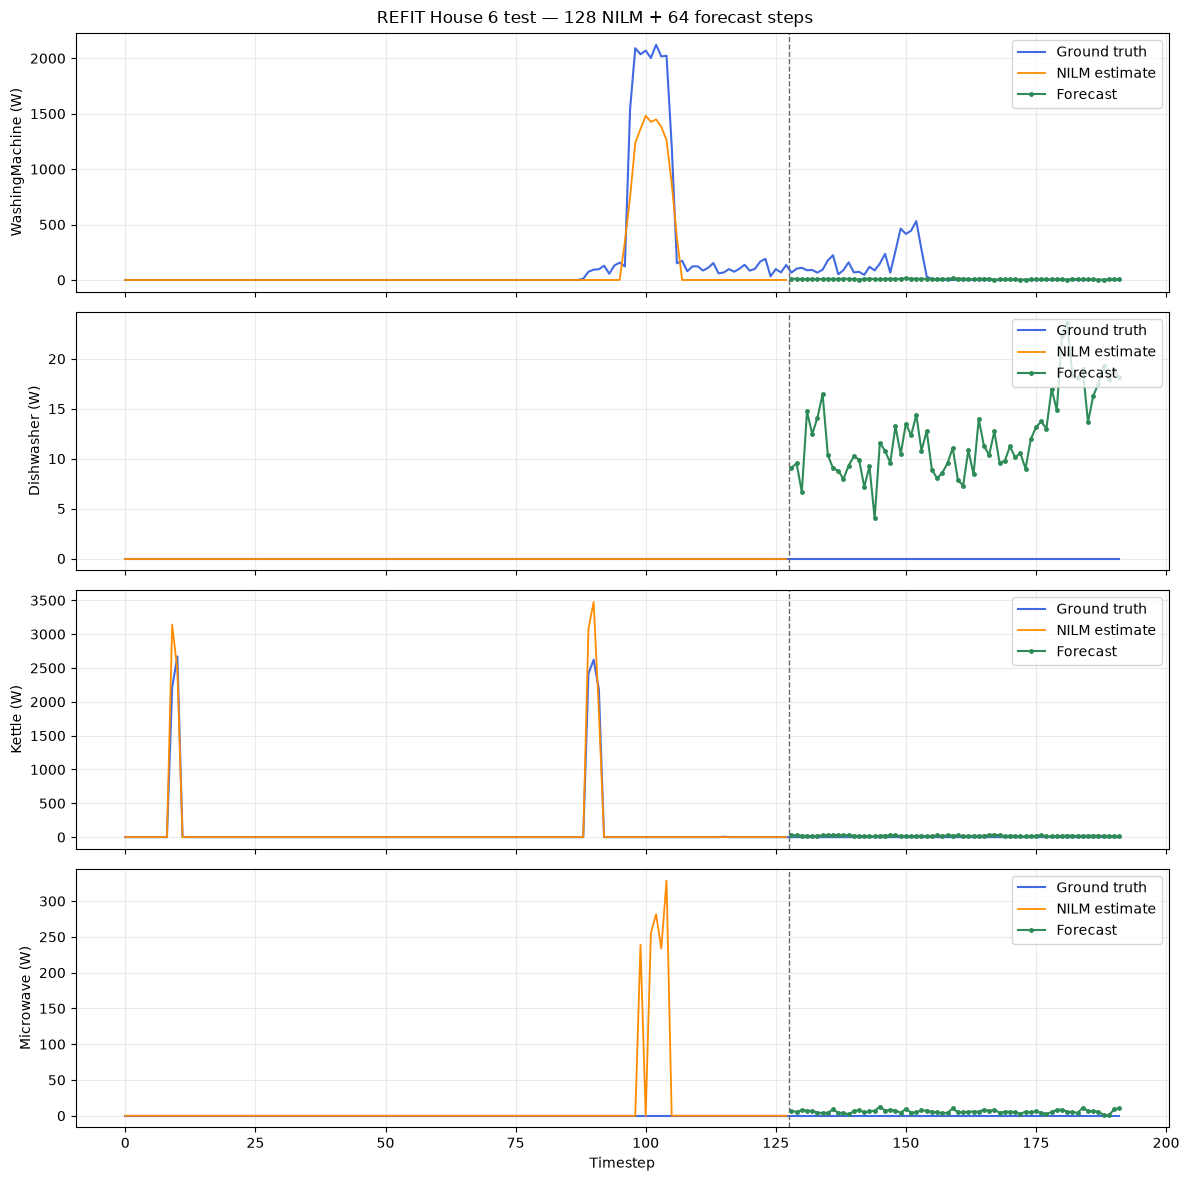

In [32]:
# Plot the selected House 6 test sample: NILM estimates first, then each device's forecast.
true_history_w = scaler.inverse_transform_appliance(
    torch.as_tensor(appliance_y, dtype=torch.float32).unsqueeze(0).to(DEVICE)
).squeeze(0).cpu().numpy()
true_future_w = scaler.inverse_transform_appliance(
    torch.as_tensor(future_y, dtype=torch.float32).unsqueeze(0).to(DEVICE)
).squeeze(0).cpu().numpy()
nilm_history_w = scaler.inverse_transform_appliance(nilm_prediction).squeeze(0).cpu().numpy()
# Match repo evaluation post-processing: suppress appliance estimates below its threshold.
for app_idx in range(N_APPLIANCES):
    nilm_history_w[app_idx, nilm_history_w[app_idx] < forecast_thresholds[app_idx]] = 0
forecast_values_w = []
with torch.no_grad():
    for app_idx, app_name in enumerate(APPLIANCES):
        scaled_forecast = forecast_models[app_name](nilm_prediction[:, app_idx:app_idx + 1, :])
        forecast_values_w.append(
            np.maximum(inverse_one_appliance(scaled_forecast.squeeze(0).cpu().numpy(), app_idx), 0)
        )
forecast_values_w = np.stack(forecast_values_w)
steps = np.arange(WINDOW_SIZE + FORECAST_HORIZON)
fig, axes = plt.subplots(N_APPLIANCES, 1, figsize=(12, 3.0 * N_APPLIANCES), sharex=True, squeeze=False)
for app_idx, app_name in enumerate(APPLIANCES):
    ax = axes[app_idx, 0]
    truth = np.concatenate([true_history_w[app_idx], true_future_w[app_idx]])
    ax.plot(steps, truth, color="royalblue", linewidth=1.5, label="Ground truth")
    ax.plot(steps[:WINDOW_SIZE], nilm_history_w[app_idx], color="darkorange", linewidth=1.3, label="NILM estimate")
    ax.plot(steps[WINDOW_SIZE:], forecast_values_w[app_idx], color="seagreen", marker="o", markersize=2.5, label="Forecast")
    ax.axvline(WINDOW_SIZE - 0.5, color="0.4", linestyle="--", linewidth=1)
    ax.set_ylabel(f"{app_name} (W)")
    ax.grid(alpha=.25)
    ax.legend(loc="upper right")
axes[-1, 0].set_xlabel("Timestep")
fig.suptitle(f"REFIT House {HOUSE_ID} test — {WINDOW_SIZE} NILM + {FORECAST_HORIZON} forecast steps")
fig.tight_layout()
plt.show()
